In [4]:
import pandas as pd

# 1. Veriyi yükleyin (Dosya yolunu kendi sisteminize göre güncelleyin)
train_df = pd.read_csv("train.csv")

# 2. Genel Bilgiler (Sütun isimleri, veri tipleri ve eksik veri durumu)
print("--- GENEL BİLGİLER (INFO) ---")
train_df.info()

# 3. Sütun İsimleri (Hedef değişkenin gerçek adını bulmak için)
print("\n--- SÜTUN İSİMLERİ ---")
print(train_df.columns.tolist())

# 4. Kategorik Sütunların Tespiti (Sayısal olmayan veriler)
kategorik_sutunlar = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
print("\n--- KATEGORİK SÜTUNLAR ---")
print(kategorik_sutunlar)

# 5. İlk 5 Satırın Görünümü
print("\n--- İLK 5 SATIR ---")
display(train_df.head())

--- GENEL BİLGİLER (INFO) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           6913

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [7]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. Verileri Yükle (Dosya yollarını kendi ortamına göre ayarla)
print("Veriler yükleniyor...")
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# 2. Hedef (Target) ve Özellikleri (Features) Ayır
TARGET = 'addicted_label'

# Eğitim verisi
X = train_df.drop(columns=['id', TARGET])
y = train_df[TARGET]

# Test verisi (Tahmin yapacağımız dosya)
test_ids = test_df['id']
X_test = test_df.drop(columns=['id'])

# 3. Kategorik Değişkenleri LightGBM'in Anlayacağı Formata Çevir
kategorik_sutunlar = ['gender', 'stress_level', 'academic_work_impact']

for col in kategorik_sutunlar:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 4. Eğitim ve Doğrulama (Validation) Setlerini Ayır
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. LightGBM Modelini Kur ve Eğit
print("Model eğitiliyor...")
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Callbacks ile erken durdurma
callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=True)]

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=callbacks
)

# 6. Kendi İçimizdeki ROC-AUC Skorunu Kontrol Et
val_preds = model.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, val_preds)
print(f"\n>>> Modelin Validation ROC-AUC Skoru: {auc_score:.5f} <<<")

# 7. Asıl Test Seti Üzerinde Tahmin Yap
print("\nTest verisi için tahminler oluşturuluyor...")
test_preds = model.predict_proba(X_test)[:, 1]

# 8. KAGGLE'IN İSTEDİĞİ ORİJİNAL FORMATTA DOSYAYI OLUŞTUR (DÜZELTİLEN KISIM)
# Sütun isimlerini tarayıcı çevirisine göre değil, orijinal verideki gibi 'id' ve 'addicted_label' yaptık.
submission = pd.DataFrame({
    'id': test_ids,
    'addicted_label': test_preds
})

# Dosyayı kaydet
submission.to_csv("benim_ilk_tahminim.csv", index=False)
print("BAŞARILI! 'benim_ilk_tahminim.csv' dosyası hazır. Kaggle'a yükleyebilirsin!")

Veriler yükleniyor...
Model eğitiliyor...
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1957
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's auc: 0.961702	valid_0's binary_logloss: 0.253409

>>> Modelin Validation ROC-AUC Skoru: 0.96170 <<<

Test verisi için tahminler oluşturuluyor...
BAŞARILI! 'benim_ilk_tahminim.csv' dosyası hazır. Kaggle'a yükleyebilirsin!


In [8]:
import pandas as pd

# Veriyi yükleme (Zaten yüklüyse bu satırı atlayabilirsiniz)
train_df = pd.read_csv("train.csv")

# 1. Sayısal Değişkenlerin Betimsel İstatistikleri
# .T (Transpoz) kullanarak sütunları satıra alıyoruz ki tablo ekrana daha rahat sığsın
print("--- SAYISAL VERİLERİN BETİMSEL İSTATİSTİKLERİ ---")
display(train_df.describe().T)

# 2. Kategorik Değişkenlerin Betimsel İstatistikleri
print("\n--- KATEGORİK VERİLERİN BETİMSEL İSTATİSTİKLERİ ---")
display(train_df.describe(include=['object', 'category']).T)

# 3. Eksik Veri Oranları (%)
print("\n--- EKSİK VERİ ORANLARI (%) ---")
eksik_oran = (train_df.isnull().sum() / len(train_df)) * 100
# Sadece eksik verisi olan sütunları büyükten küçüğe sıralayarak göster
display(eksik_oran[eksik_oran > 0].sort_values(ascending=False))

--- SAYISAL VERİLERİN BETİMSEL İSTATİSTİKLERİ ---


,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56



--- KATEGORİK VERİLERİN BETİMSEL İSTATİSTİKLERİ ---


,count,unique,top,freq
gender,662335,3,Male,223662
stress_level,636221,3,High,220873
academic_work_impact,647145,2,Yes,330566



--- EKSİK VERİ ORANLARI (%) ---


social_media_hours         19.381112
gaming_hours               18.343461
weekend_screen_time        16.208855
daily_screen_time_hours    13.864376
app_opens_per_day          11.673940
notifications_per_day       9.775388
stress_level                7.976638
work_study_hours            7.451592
sleep_hours                 6.433612
academic_work_impact        6.396584
gender                      4.199494
age                         4.184307
dtype: float64

In [9]:
import pandas as pd
import numpy as np

print("Veriler yükleniyor...")
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

def veri_on_isleme(df):
    df_processed = df.copy()
    
    # 1. KATEGORİK EKSİK VERİLERİ DOLDURMA
    kategorik_sutunlar = ['gender', 'stress_level', 'academic_work_impact']
    for col in kategorik_sutunlar:
        # Boş olanları 'Unknown' olarak doldur
        df_processed[col] = df_processed[col].fillna('Unknown')
        # LightGBM için tekrar kategori tipine çevir
        df_processed[col] = df_processed[col].astype('category')

    # 2. SAYISAL EKSİK VERİLER İÇİN GÖLGE SÜTUNLAR (Missing Indicators)
    # Kritik sütunların boş bırakılması bağımlılık göstergesi olabilir
    kritik_eksikler = ['social_media_hours', 'gaming_hours', 'weekend_screen_time', 'daily_screen_time_hours']
    for col in kritik_eksikler:
        df_processed[f'{col}_is_missing'] = df_processed[col].isnull().astype(int)

    # 3. SAYISAL EKSİK VERİLERİ DOLDURMA (Medyan ile)
    sayisal_sutunlar = df_processed.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
    # id, hedef değişken ve yeni oluşturduğumuz is_missing sütunlarını çıkarıyoruz
    sayisal_sutunlar = [col for col in sayisal_sutunlar if col not in ['id', 'addicted_label'] and not col.endswith('_is_missing')]
    
    for col in sayisal_sutunlar:
        medyan_degeri = df_processed[col].median()
        df_processed[col] = df_processed[col].fillna(medyan_degeri)

    # 4. YENİ ÖZELLİKLER ÜRETME (Feature Engineering)
    # Hafta sonu ile hafta içi farkı (Pozitifse hafta sonu çok telefona bakıyor demektir)
    df_processed['weekend_vs_weekday_diff'] = df_processed['weekend_screen_time'] - df_processed['daily_screen_time_hours']
    
    # Ekran süresinin ne kadarı sosyal medyaya ait? (Sıfıra bölünmeyi önlemek için +0.1 ekliyoruz)
    df_processed['social_media_ratio'] = df_processed['social_media_hours'] / (df_processed['daily_screen_time_hours'] + 0.1)
    
    # Uyku açığı (8 saat ideal kabul edilerek)
    df_processed['sleep_deficit'] = 8.0 - df_processed['sleep_hours']
    
    # Uygulama açma başına düşen bildirim (Bildirim yığılması)
    df_processed['notifications_per_app_open'] = df_processed['notifications_per_day'] / (df_processed['app_opens_per_day'] + 0.1)

    return df_processed

print("Eksik veriler işleniyor ve yeni özellikler üretiliyor...")
# İşlemleri hem Train hem de Test verisine GÜVENLE (veri sızıntısı olmadan) uyguluyoruz
X_train_processed = veri_on_isleme(train_df)
X_test_processed = veri_on_isleme(test_df)

print("Veri ön işleme tamamlandı!")
print(f"Yeni Eğitim Seti Boyutu: {X_train_processed.shape}")

Veriler yükleniyor...
Eksik veriler işleniyor ve yeni özellikler üretiliyor...
Veri ön işleme tamamlandı!
Yeni Eğitim Seti Boyutu: (691369, 22)


--- HEDEF DEĞİŞKEN ('addicted_label') İLE KORELASYON ---
addicted_label                        1.000000
daily_screen_time_hours               0.567548
weekend_screen_time                   0.540076
social_media_hours                    0.477347
work_study_hours                      0.241706
gaming_hours                          0.185157
social_media_ratio                    0.118373
app_opens_per_day                     0.059711
sleep_hours                           0.041163
age                                   0.003986
daily_screen_time_hours_is_missing    0.001658
weekend_screen_time_is_missing        0.001191
gaming_hours_is_missing               0.001128
id                                    0.001097
social_media_hours_is_missing        -0.000011
weekend_vs_weekday_diff              -0.010931
notifications_per_day                -0.010990
sleep_deficit                        -0.041163
notifications_per_app_open           -0.042241
Name: addicted_label, dtype: float64


Isı haritas

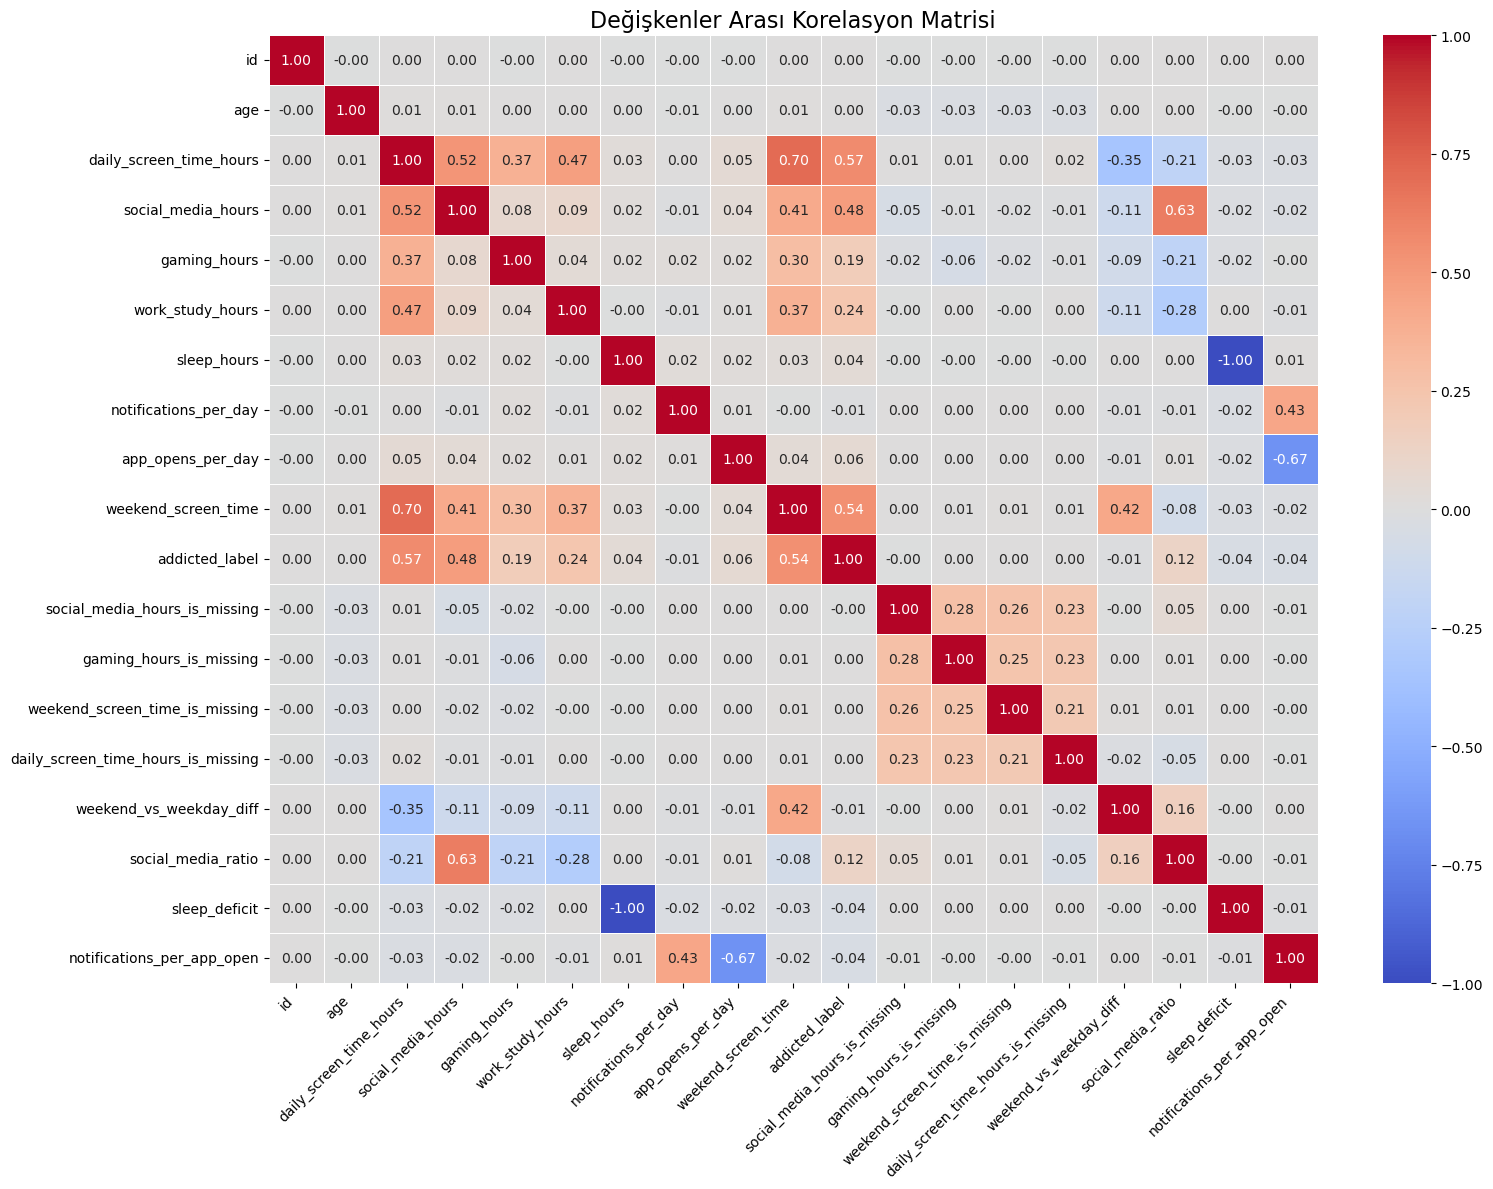

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kategorik verilerin korelasyonu standart yöntemle ölçülemez, bu yüzden sadece sayısal verileri alıyoruz.
# Bir önceki adımda ürettiğimiz 'X_train_processed' verisini kullanıyoruz.
sayisal_df = X_train_processed.select_dtypes(include=['float64', 'int64', 'int32'])

# Korelasyon matrisini hesapla
corr_matrix = sayisal_df.corr()

# 1. HEDEF DEĞİŞKEN İLE KORELASYON
print("--- HEDEF DEĞİŞKEN ('addicted_label') İLE KORELASYON ---")
# Hedef değişkene göre sırala (En yüksek pozitiften, en yüksek negatife doğru)
hedef_korelasyonu = corr_matrix['addicted_label'].sort_values(ascending=False)
print(hedef_korelasyonu)
print("\n" + "="*50 + "\n")

# 2. TÜM DEĞİŞKENLERİN KENDİ ARALARINDAKİ KORELASYONU (ISI HARİTASI)
print("Isı haritası oluşturuluyor, lütfen grafiğin çizilmesini bekleyin...")
plt.figure(figsize=(16, 12)) # Grafiğin boyutu

# Isı haritasını çizdiriyoruz
# annot=True: Kutuların içine sayıları yazar
# cmap='coolwarm': Kırmızı renkler yüksek pozitif, mavi renkler yüksek negatif ilişkiyi gösterir
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)

plt.title("Değişkenler Arası Korelasyon Matrisi", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. GEREKSİZ VE ÇAKILAN SÜTUNLARI ÇIKARMA
# 'id' modele hiçbir şey katmaz.
# 'sleep_deficit' ise sleep_hours ile %100 aynı bilgiyi içeriyor, onu da atıyoruz.
# Eğer yaş (age) veya bildirim sayılarını atmak istersen buraya ekleyebilirsin ama LightGBM'e bırakmak daha iyidir.
drop_cols = ['id', 'sleep_deficit']

X_train_final = X_train_processed.drop(columns=drop_cols)
X_test_final = X_test_processed.drop(columns=drop_cols)

# Hedef değişkeni ayırma
y = X_train_final['addicted_label']
X = X_train_final.drop(columns=['addicted_label'])

# 2. EĞİTİM VE DOĞRULAMA SETİNİ AYIRMA
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. KAGGLE ŞAMPİYONLARININ KULLANDIĞI HİPERPARAMETRELER (Tuning)
print("Gelişmiş Model eğitiliyor...")
model_tuned = lgb.LGBMClassifier(
    n_estimators=2000,         # Ağaç sayısını artırdık
    learning_rate=0.03,        # Daha yavaş ve sindirerek öğrenmesi için hızı düşürdük
    max_depth=7,               # Aşırı ezberlemeyi (overfitting) önlemek için derinlik sınırı
    num_leaves=64,             # Ağaç başına yaprak sayısı
    subsample=0.8,             # Her ağaçta verinin %80'ini rastgele kullan (Overfit engeller)
    colsample_bytree=0.8,      # Her ağaçta sütunların %80'ini rastgele kullan (Overfit engeller)
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

callbacks = [lgb.early_stopping(stopping_rounds=100, verbose=True)]

model_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=callbacks
)

# 4. SKOR KONTROLÜ VE DOSYA OLUŞTURMA
val_preds = model_tuned.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, val_preds)
print(f"\n>>> Yeni Feature Engineering ve Tuning Sonrası ROC-AUC Skoru: {auc_score:.5f} <<<")

print("\nKaggle teslim dosyası hazırlanıyor...")
test_preds = model_tuned.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    'id': test_df['id'],  # Orijinal test ID'lerini alıyoruz
    'addicted_label': test_preds
})

submission.to_csv("feature_eng_submission.csv", index=False)
print("BAŞARILI! 'feature_eng_submission.csv' dosyası hazır. Kaggle'a yükleyip değişimi görebilirsin!")

Gelişmiş Model eğitiliyor...
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2728
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

In [13]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. Stratified K-Fold Ayarları
FOLDS = 5
# StratifiedKFold, dengesiz %71'e %29'luk dağılımın her 5 parçada da aynı oranda korunmasını sağlar.
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

# OOF (Out-Of-Fold) tahminleri ve asıl test tahminlerini tutacağımız boş diziler
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test_final))

print(f"--- {FOLDS}-Fold Cross Validation Eğitimi Başlıyor ---\n")

# 2. Döngü ile 5 Farklı Model Eğitimi
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"[Fold {fold + 1}/{FOLDS}] Eğitiliyor...")

    # Veriyi eğitim ve doğrulama seti olarak index numaralarına göre bölme
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

    # Model Tanımı (Bulduğumuz en iyi hiperparametrelerle)
    model_cv = lgb.LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=7,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42 + fold, # Her fold'da rastgeleliği ufakça değiştirmek model çeşitliliğini artırır
        n_jobs=-1
    )

    # Erken durdurma (Ekran kirlenmesin diye verbose'u kapattık/False yaptık)
    callbacks = [lgb.early_stopping(stopping_rounds=100, verbose=False)]

    # Modeli Eğitme
    model_cv.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        eval_metric='auc',
        callbacks=callbacks
    )

    # Doğrulama (Validation) Seti İçin Tahmin Yap ve OOF Dizisine Kaydet
    fold_val_preds = model_cv.predict_proba(X_val_fold)[:, 1]
    oof_preds[val_idx] = fold_val_preds

    # Bu Fold'un ROC-AUC Skorunu Hesapla
    fold_auc = roc_auc_score(y_val_fold, fold_val_preds)
    print(f"--> Fold {fold + 1} ROC-AUC Skoru: {fold_auc:.5f}\n")

    # KAGGLE TEST SETİ TAHMİNİ (ENSEMBLE)
    # 5 fold olduğu için her modelin test tahminini 5'e bölerek (ortalamasını alarak) ana diziye ekliyoruz.
    test_preds += model_cv.predict_proba(X_test_final)[:, 1] / FOLDS

# 3. Genel Başarıyı Hesaplama ve Teslim Dosyasını Oluşturma
genel_auc = roc_auc_score(y, oof_preds)
print("="*50)
print(f"🚀 K-FOLD GENEL (OOF) ROC-AUC SKORU: {genel_auc:.5f}")
print("="*50)

# Kaggle için CSV oluşturma
submission_cv = pd.DataFrame({
    'id': test_df['id'], # test_df hafızada yoksa bir önceki adımdaki gibi pd.read_csv("test.csv") ile id'yi alabilirsiniz
    'addicted_label': test_preds
})

submission_cv.to_csv("kfold_submission.csv", index=False)
print("\nBAŞARILI! 'kfold_submission.csv' dosyası Kaggle'a yüklenmek üzere hazır!")

--- 5-Fold Cross Validation Eğitimi Başlıyor ---

[Fold 1/5] Eğitiliyor...
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008570 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2729
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [14]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. Kategorik Sütunları Belirleme
# CatBoost kategorik verileri (metinleri veya kategorileri) doğrudan sayıya çevirmeden kendi içinde anlar
kategorik_sutunlar = ['gender', 'stress_level', 'academic_work_impact']

FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

oof_preds_cb = np.zeros(len(X))
test_preds_cb = np.zeros(len(X_test_final))

print(f"--- CatBoost {FOLDS}-Fold Eğitimi Başlıyor ---\n")

# 2. CatBoost 5-Fold Eğitimi
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"[Fold {fold + 1}/{FOLDS}] CatBoost Eğitiliyor...")
    
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    # CatBoost Modeli (En iyi başlangıç parametreleriyle)
    model_cb = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        eval_metric='AUC',
        random_seed=42 + fold,
        auto_class_weights='Balanced', # Dengesiz veriler için sınıfları dengeler
        cat_features=kategorik_sutunlar, # Kategorik sütunları modele tanıtıyoruz
        verbose=False # Ekran çok fazla yazıyla dolmasın diye kapattık
    )
    
    # Modeli Eğitme
    model_cb.fit(
        X_train_fold, y_train_fold,
        eval_set=(X_val_fold, y_val_fold),
        early_stopping_rounds=100,
        use_best_model=True
    )
    
    # Doğrulama (Validation) Tahmini
    fold_val_preds = model_cb.predict_proba(X_val_fold)[:, 1]
    oof_preds_cb[val_idx] = fold_val_preds
    
    fold_auc = roc_auc_score(y_val_fold, fold_val_preds)
    print(f"--> Fold {fold + 1} CatBoost ROC-AUC: {fold_auc:.5f}\n")
    
    # Test Tahmini
    test_preds_cb += model_cb.predict_proba(X_test_final)[:, 1] / FOLDS

# CatBoost'un kendi iç skoru
genel_auc_cb = roc_auc_score(y, oof_preds_cb)
print("="*50)
print(f"🐱 CATBOOST GENEL (OOF) ROC-AUC SKORU: {genel_auc_cb:.5f}")
print("="*50)

# CatBoost'un tahminlerini kaydet
submission_cb = pd.DataFrame({
    'id': test_df['id'], 
    'addicted_label': test_preds_cb
})
submission_cb.to_csv("catboost_submission.csv", index=False)

# ---------------------------------------------------------
# 3. BLENDING (HARMANLAMA) ZAMANI - SİHRİN GERÇEKLEŞTİĞİ YER
# ---------------------------------------------------------
print("\n--- 🌟 MODELLER HARMANLANIYOR (BLENDING) 🌟 ---")

# Bir önceki adımdaki LightGBM dosyasını okuyoruz
lgb_sub = pd.read_csv("kfold_submission.csv")

# İki güçlü modelin tahminlerinin %50-%50 ortalamasını alıyoruz
blended_preds = (lgb_sub['addicted_label'] + submission_cb['addicted_label']) / 2.0

# Nihai "Yenilmezler" dosyasını oluştur
submission_blend = pd.DataFrame({
    'id': lgb_sub['id'],
    'addicted_label': blended_preds
})
submission_blend.to_csv("blended_submission.csv", index=False)

print("BAŞARILI! 'blended_submission.csv' dosyası Kaggle'a yüklenmek üzere hazır!")

--- CatBoost 5-Fold Eğitimi Başlıyor ---

[Fold 1/5] CatBoost Eğitiliyor...
--> Fold 1 CatBoost ROC-AUC: 0.95822

[Fold 2/5] CatBoost Eğitiliyor...
--> Fold 2 CatBoost ROC-AUC: 0.95899

[Fold 3/5] CatBoost Eğitiliyor...
--> Fold 3 CatBoost ROC-AUC: 0.95902

[Fold 4/5] CatBoost Eğitiliyor...
--> Fold 4 CatBoost ROC-AUC: 0.95995

[Fold 5/5] CatBoost Eğitiliyor...
--> Fold 5 CatBoost ROC-AUC: 0.95862

🐱 CATBOOST GENEL (OOF) ROC-AUC SKORU: 0.95896

--- 🌟 MODELLER HARMANLANIYOR (BLENDING) 🌟 ---
BAŞARILI! 'blended_submission.csv' dosyası Kaggle'a yüklenmek üzere hazır!


In [16]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [optuna]


In [17]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

print("--- 🌟 OPTUNA İLE HİPERPARAMETRE AVI BAŞLIYOR 🌟 ---")

# Optuna'nın hızlı çalışması için veriyi %80-%20 olarak ayırıyoruz
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Optuna için Amaç (Objective) Fonksiyonu
def objective(trial):
    # Optuna'nın deneyeceği parametre aralıkları
    param = {
        'n_estimators': 1500, # Sabit tutuyoruz, early_stopping durduracak
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Modeli kur
    model = lgb.LGBMClassifier(**param)
    
    # Eğit
    callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
    model.fit(
        X_opt_train, y_opt_train,
        eval_set=[(X_opt_val, y_opt_val)],
        eval_metric='auc',
        callbacks=callbacks
    )
    
    # Tahmin ve Skor
    preds = model.predict_proba(X_opt_val)[:, 1]
    auc = roc_auc_score(y_opt_val, preds)
    
    return auc

# Optuna Çalışmasını (Study) Başlat
# direction='maximize' diyoruz çünkü ROC-AUC skorunu en tepeye çıkarmak istiyoruz
study = optuna.create_study(direction='maximize', study_name="LGBM_Optimizasyonu")

# n_trials=20: 20 farklı kombinasyon deneyecek. Süren varsa bunu 30 veya 50 yapabilirsin!
study.optimize(objective, n_trials=20)

print("\n" + "="*50)
print(f"🔥 BULUNAN EN İYİ ROC-AUC SKORU: {study.best_value:.5f}")
print("🔥 EN İYİ PARAMETRELER:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")
print("="*50)

[I 2026-08-26 23:58:59,662] A new study created in memory with name: LGBM_Optimizasyonu


--- 🌟 OPTUNA İLE HİPERPARAMETRE AVI BAŞLIYOR 🌟 ---
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006678 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2728
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[I 2026-08-26 23:59:20,460] Trial 0 finished with value: 0.9623247238296172 and parameters: {'learning_rate': 0.021785031975507435, 'max_depth': 10, 'num_leaves': 122, 'subsample': 0.9472752363926333, 'colsample_bytree': 0.7361687803624153, 'min_child_samples': 40}. Best is trial 0 with value: 0.9623247238296172.


[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2728
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-08-26 23:59:34,683] Trial 1 finished with value: 0.961978936247651 and parameters: {'learning_rate': 0.052437129842082576, 'max_depth': 5, 'num_leaves': 51, 'subsample': 0.7924791975182712, 'colsample_bytree': 0.7202117560899175, 'min_child_samples': 95}. Best is trial 0 with value: 0.9623247238296172.


...

[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2728
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-08-27 00:04:18,063] Trial 18 finished with value: 0.9601231073341415 and parameters: {'learning_rate': 0.022777795572658993, 'max_depth': 6, 'num_leaves': 68, 'subsample': 0.6596116682280335, 'colsample_bytree': 0.5527559319298728, 'min_child_samples': 78}. Best is trial 11 with value: 0.9630180585389227.


[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2728
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-08-27 00:04:41,979] Trial 19 finished with value: 0.9621735117732569 and parameters: {'learning_rate': 0.024465622447611184, 'max_depth': 9, 'num_leaves': 150, 'subsample': 0.8644196329041479, 'colsample_bytree': 0.9923166210832581, 'min_child_samples': 90}. Best is trial 11 with value: 0.9630180585389227.



🔥 BULUNAN EN İYİ ROC-AUC SKORU: 0.96302
🔥 EN İYİ PARAMETRELER:
    'learning_rate': 0.0977811981851585,
    'max_depth': 7,
    'num_leaves': 106,
    'subsample': 0.5133567281701968,
    'colsample_bytree': 0.5174818158212963,
    'min_child_samples': 96,


In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. VERİLERİ YÜKLE
print("Veriler yükleniyor...")
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

def gelismis_veri_on_isleme(df):
    df_proc = df.copy()
    
    # Kategorik Eksikler
    kategorik_sutunlar = ['gender', 'stress_level', 'academic_work_impact']
    for col in kategorik_sutunlar:
        df_proc[col] = df_proc[col].fillna('Unknown').astype('category')

    # Sayısal Eksik Göstergeleri (Missing Indicators)
    kritik_eksikler = ['social_media_hours', 'gaming_hours', 'weekend_screen_time', 'daily_screen_time_hours']
    for col in kritik_eksikler:
        df_proc[f'{col}_is_missing'] = df_proc[col].isnull().astype(int)

    # Sayısal Eksikleri Medyanla Doldur
    sayisal_sutunlar = [c for c in df_proc.select_dtypes(include=['float64', 'int64']).columns 
                        if c not in ['id', 'addicted_label'] and not c.endswith('_is_missing')]
    
    for col in sayisal_sutunlar:
        df_proc[col] = df_proc[col].fillna(df_proc[col].median())

    # --- YENİ ÖZELLİK MÜHENDİSLİĞİ (V2) ---
    # 1. Sosyal Medya Oranı
    df_proc['social_media_ratio'] = df_proc['social_media_hours'] / (df_proc['daily_screen_time_hours'] + 0.1)
    
    # 2. Hafta Sonu Farkı ve Oranı
    df_proc['weekend_vs_weekday_diff'] = df_proc['weekend_screen_time'] - df_proc['daily_screen_time_hours']
    df_proc['weekend_ratio'] = df_proc['weekend_screen_time'] / (df_proc['daily_screen_time_hours'] + 0.1)
    
    # 3. Bildirim ve Açılış Dinamikleri
    df_proc['notifications_per_app_open'] = df_proc['notifications_per_day'] / (df_proc['app_opens_per_day'] + 0.1)
    df_proc['mins_per_app_open'] = (df_proc['daily_screen_time_hours'] * 60) / (df_proc['app_opens_per_day'] + 0.1)
    
    # 4. Eğlence / Çalışma Oranı
    df_proc['entertainment_hours'] = df_proc['social_media_hours'] + df_proc['gaming_hours']
    df_proc['fun_to_work_ratio'] = df_proc['entertainment_hours'] / (df_proc['work_study_hours'] + 0.1)
    
    # 5. Ekran & Sosyal Medya Çarpımı (Doğrusal Olmayan Etkileşim)
    df_proc['screen_x_social'] = df_proc['daily_screen_time_hours'] * df_proc['social_media_hours']

    return df_proc

print("Özellik mühendisliği uygulanıyor...")
train_proc = gelismis_veri_on_isleme(train_df)
test_proc = gelismis_veri_on_isleme(test_df)

# Gereksiz sütunları çıkar
drop_cols = ['id']
X = train_proc.drop(columns=drop_cols + ['addicted_label'])
y = train_proc['addicted_label']
X_test = test_proc.drop(columns=drop_cols)

# 2. 5-FOLD STRATIFIED K-FOLD + OPTUNA PARAMETRELERİ
FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

print(f"\n--- {FOLDS}-Fold Model Eğitimi Başlıyor ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_f, y_train_f = X.iloc[train_idx], y.iloc[train_idx]
    X_val_f, y_val_f = X.iloc[val_idx], y.iloc[val_idx]

    # Optuna'nın bulduğu en iyi parametreler
    model = lgb.LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.08,             # Optuna ~0.097 buldu, K-Fold için biraz daha stabil 0.08 aldık
        max_depth=7,
        num_leaves=106,
        subsample=0.51,
        colsample_bytree=0.51,
        min_child_samples=96,
        class_weight='balanced',
        random_state=42 + fold,
        n_jobs=-1
    )

    callbacks = [lgb.early_stopping(stopping_rounds=100, verbose=False)]
    
    model.fit(
        X_train_f, y_train_f,
        eval_set=[(X_val_f, y_val_f)],
        eval_metric='auc',
        callbacks=callbacks
    )

    val_pred = model.predict_proba(X_val_f)[:, 1]
    oof_preds[val_idx] = val_pred
    fold_auc = roc_auc_score(y_val_f, val_pred)
    print(f"Fold {fold+1} ROC-AUC: {fold_auc:.5f}")

    test_preds += model.predict_proba(X_test)[:, 1] / FOLDS

# Genel Skor
cv_score = roc_auc_score(y, oof_preds)
print("="*50)
print(f"🚀 NİHAİ 5-FOLD OOF ROC-AUC SKORU: {cv_score:.5f}")
print("="*50)

# Kaggle Teslim Dosyası
submission = pd.DataFrame({
    'id': test_df['id'],
    'addicted_label': test_preds
})
submission.to_csv("optuna_fe_kfold_submission.csv", index=False)
print("BAŞARILI! 'optuna_fe_kfold_submission.csv' hazır!")

Veriler yükleniyor...
Özellik mühendisliği uygulanıyor...

--- 5-Fold Model Eğitimi Başlıyor ---
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4004
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

In [19]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("--- 🐉 XGBOOST SAHAYA İNİYOR (5-FOLD CV) 🐉 ---")

# 1. XGBoost İçin Sınıf Dengesizliği Oranını Hesaplama
# XGBoost'ta 'balanced' komutu yoktur, bunun yerine Negatif Sınıf / Pozitif Sınıf oranını veririz.
# Bizde 0'lar (bağımlı olmayanlar) azınlık, 1'ler (bağımlılar) çoğunlukta.
oran = len(y[y == 0]) / len(y[y == 1])
print(f"Hesaplanan scale_pos_weight (Sınıf Dengeleme) Oranı: {oran:.4f}\n")

# 2. 5-Fold Ayarları
FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

oof_preds_xgb = np.zeros(len(X))
test_preds_xgb = np.zeros(len(X_test))

# 3. Model Eğitimi
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"[Fold {fold + 1}/{FOLDS}] XGBoost Eğitiliyor...")
    
    X_train_f, y_train_f = X.iloc[train_idx], y.iloc[train_idx]
    X_val_f, y_val_f = X.iloc[val_idx], y.iloc[val_idx]

    # XGBoost Modeli Tanımlama
    model_xgb = xgb.XGBClassifier(
        n_estimators=3000,
        learning_rate=0.03,            # XGBoost için güvenli, yavaş ve emin adımlarla öğrenme hızı
        max_depth=6,                   # LightGBM'den farklı olarak derinliği bir tık düşük tutuyoruz
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=oran,         # Veri dengesizliğini çözme
        tree_method='hist',            # Devasa verilerde (700 bin) çok hızlı çalışmasını sağlar
        enable_categorical=True,       # Kategorik ('Unknown') verileri doğrudan tanıması için
        early_stopping_rounds=100,
        eval_metric='auc',
        random_state=42 + fold,
        n_jobs=-1
    )
    
    # Modeli Eğitme (XGBoost'ta early stopping artık modelin içine yazılıyor, fit içine sadece eval_set veriyoruz)
    model_xgb.fit(
        X_train_f, y_train_f,
        eval_set=[(X_val_f, y_val_f)],
        verbose=False # Ekranı kalabalıklaştırmaması için kapattık
    )
    
    # Doğrulama (Validation) Tahmini
    val_pred = model_xgb.predict_proba(X_val_f)[:, 1]
    oof_preds_xgb[val_idx] = val_pred
    
    # Fold Skoru
    fold_auc = roc_auc_score(y_val_f, val_pred)
    print(f"--> Fold {fold + 1} XGBoost ROC-AUC: {fold_auc:.5f}\n")
    
    # Test Verisi Üzerinde Tahmin (5'e bölerek ortalama alıyoruz)
    test_preds_xgb += model_xgb.predict_proba(X_test)[:, 1] / FOLDS

# 4. Genel XGBoost Skoru
xgb_cv_score = roc_auc_score(y, oof_preds_xgb)
print("="*50)
print(f"🐉 NİHAİ XGBOOST OOF ROC-AUC SKORU: {xgb_cv_score:.5f}")
print("="*50)

# 5. Kaggle İçin Kaydet
submission_xgb = pd.DataFrame({
    'id': test_df['id'],
    'addicted_label': test_preds_xgb
})
submission_xgb.to_csv("xgboost_submission.csv", index=False)
print("BAŞARILI! 'xgboost_submission.csv' dosyası Kaggle'a yüklenmek üzere hazır!")

--- 🐉 XGBOOST SAHAYA İNİYOR (5-FOLD CV) 🐉 ---
Hesaplanan scale_pos_weight (Sınıf Dengeleme) Oranı: 0.4096

[Fold 1/5] XGBoost Eğitiliyor...
--> Fold 1 XGBoost ROC-AUC: 0.96278

[Fold 2/5] XGBoost Eğitiliyor...
--> Fold 2 XGBoost ROC-AUC: 0.96332

[Fold 3/5] XGBoost Eğitiliyor...
--> Fold 3 XGBoost ROC-AUC: 0.96363

[Fold 4/5] XGBoost Eğitiliyor...
--> Fold 4 XGBoost ROC-AUC: 0.96449

[Fold 5/5] XGBoost Eğitiliyor...
--> Fold 5 XGBoost ROC-AUC: 0.96323

🐉 NİHAİ XGBOOST OOF ROC-AUC SKORU: 0.96349
BAŞARILI! 'xgboost_submission.csv' dosyası Kaggle'a yüklenmek üzere hazır!


In [20]:
import pandas as pd

print("🌟 ŞAMPİYON MODELLER BİRLEŞTİRİLİYOR (BLENDING) 🌟")

# Önceki en iyi LightGBM (Optuna) dosyamız
lgb_sub = pd.read_csv("optuna_fe_kfold_submission.csv")

# Az önce ürettiğimiz en iyi XGBoost dosyamız
xgb_sub = pd.read_csv("xgboost_submission.csv")

# Tahminlerin %50-%50 ortalamasını alıyoruz
blended_preds = (lgb_sub['addicted_label'] + xgb_sub['addicted_label']) / 2.0

# Yeni teslim dosyasını oluştur
final_blend = pd.DataFrame({
    'id': lgb_sub['id'],
    'addicted_label': blended_preds
})

final_blend.to_csv("lgbm_xgb_blend_submission.csv", index=False)
print("BAŞARILI! 'lgbm_xgb_blend_submission.csv' dosyası hazır. Hemen Kaggle'a yükle!")

🌟 ŞAMPİYON MODELLER BİRLEŞTİRİLİYOR (BLENDING) 🌟
BAŞARILI! 'lgbm_xgb_blend_submission.csv' dosyası hazır. Hemen Kaggle'a yükle!


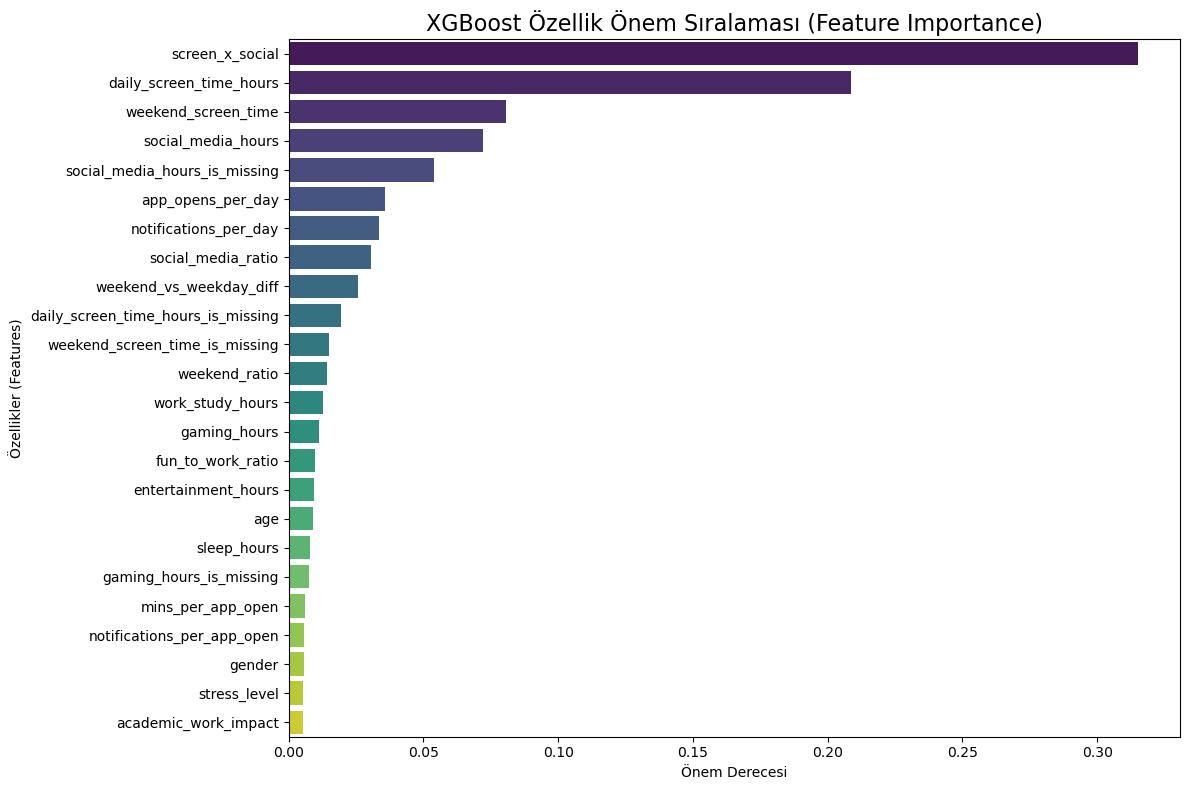

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Son eğitilen XGBoost modelinin özellik önem (Feature Importance) değerlerini alıyoruz
feature_importances = model_xgb.feature_importances_

# Sütun isimleri ve önem derecelerini bir tabloya koyuyoruz
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Büyükten küçüğe sıralıyoruz
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Grafiği çizdiriyoruz
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("XGBoost Özellik Önem Sıralaması (Feature Importance)", fontsize=16)
plt.xlabel("Önem Derecesi")
plt.ylabel("Özellikler (Features)")
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("--- 🧹 BAHAR TEMİZLİĞİ BAŞLIYOR: GEREKSİZ ÖZELLİKLER ATILIYOR 🧹 ---")

# 1. VERİLERİ YÜKLE
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

def saf_veri_on_isleme(df):
    df_proc = df.copy()
    
    # Sadece işe yarayan eksik veri göstergelerini bırakıyoruz ('gaming_hours_is_missing' atıldı)
    kritik_eksikler = ['social_media_hours', 'weekend_screen_time', 'daily_screen_time_hours']
    for col in kritik_eksikler:
        df_proc[f'{col}_is_missing'] = df_proc[col].isnull().astype(int)

    # Sayısal Eksikleri Medyanla Doldur
    sayisal_sutunlar = [c for c in df_proc.select_dtypes(include=['float64', 'int64']).columns 
                        if c not in ['id', 'addicted_label'] and not c.endswith('_is_missing')]
    
    for col in sayisal_sutunlar:
        df_proc[col] = df_proc[col].fillna(df_proc[col].median())

    # --- EN GÜÇLÜ ÖZELLİKLER (Zayıflar Üretilmiyor) ---
    df_proc['social_media_ratio'] = df_proc['social_media_hours'] / (df_proc['daily_screen_time_hours'] + 0.1)
    df_proc['weekend_vs_weekday_diff'] = df_proc['weekend_screen_time'] - df_proc['daily_screen_time_hours']
    df_proc['weekend_ratio'] = df_proc['weekend_screen_time'] / (df_proc['daily_screen_time_hours'] + 0.1)
    df_proc['entertainment_hours'] = df_proc['social_media_hours'] + df_proc['gaming_hours']
    df_proc['fun_to_work_ratio'] = df_proc['entertainment_hours'] / (df_proc['work_study_hours'] + 0.1)
    
    # Yıldız Özelliğimiz:
    df_proc['screen_x_social'] = df_proc['daily_screen_time_hours'] * df_proc['social_media_hours']

    # ÇÖP ÖZELLİKLERİ TAMAMEN SİL
    cop_ozellikler = ['academic_work_impact', 'stress_level', 'gender']
    df_proc = df_proc.drop(columns=cop_ozellikler, errors='ignore')

    return df_proc

print("Veri ön işleme ve temizlik uygulanıyor...")
train_proc = saf_veri_on_isleme(train_df)
test_proc = saf_veri_on_isleme(test_df)

# X ve y'yi ayır
X = train_proc.drop(columns=['id', 'addicted_label'])
y = train_proc['addicted_label']
X_test = test_proc.drop(columns=['id'])

# 2. 5-FOLD K-FOLD + OPTUNA PARAMETRELERİ İLE EĞİTİM
FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

print(f"\n--- 🚀 SAF LIGHTGBM MODELİ EĞİTİLİYOR ({FOLDS}-Fold) 🚀 ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_f, y_train_f = X.iloc[train_idx], y.iloc[train_idx]
    X_val_f, y_val_f = X.iloc[val_idx], y.iloc[val_idx]

    # Rekor kıran parametrelerimiz
    model = lgb.LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.08,             
        max_depth=7,
        num_leaves=106,
        subsample=0.51,
        colsample_bytree=0.51,
        min_child_samples=96,
        class_weight='balanced',
        random_state=42 + fold,
        n_jobs=-1
    )

    callbacks = [lgb.early_stopping(stopping_rounds=100, verbose=False)]
    
    model.fit(
        X_train_f, y_train_f,
        eval_set=[(X_val_f, y_val_f)],
        eval_metric='auc',
        callbacks=callbacks
    )

    val_pred = model.predict_proba(X_val_f)[:, 1]
    oof_preds[val_idx] = val_pred
    fold_auc = roc_auc_score(y_val_f, val_pred)
    print(f"Fold {fold+1} ROC-AUC: {fold_auc:.5f}")

    test_preds += model.predict_proba(X_test)[:, 1] / FOLDS

# Genel Skor
cv_score = roc_auc_score(y, oof_preds)
print("="*50)
print(f"🌟 TEMİZLENMİŞ OOF ROC-AUC SKORU: {cv_score:.5f}")
print("="*50)

# Kaggle Teslim Dosyası
submission = pd.DataFrame({
    'id': test_df['id'],
    'addicted_label': test_preds
})
submission.to_csv("lgbm_pruned_submission.csv", index=False)
print("BAŞARILI! 'lgbm_pruned_submission.csv' Kaggle'a yüklenmek üzere hazır!")

--- 🧹 BAHAR TEMİZLİĞİ BAŞLIYOR: GEREKSİZ ÖZELLİKLER ATILIYOR 🧹 ---
Veri ön işleme ve temizlik uygulanıyor...

--- 🚀 SAF LIGHTGBM MODELİ EĞİTİLİYOR (5-Fold) 🚀 ---
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3478
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [1]:
pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 707.1 kB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 MB 2.1 MB/s  0:00:56m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 3.2 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: setuptools
    Found existing installation: setuptools 72.1.0
    Uninstalling setuptools-72.1.0:
      Successfully uninstalled setuptools-72.1.0 0/3 [setuptools]
  Attempting uninstall: torch━━━━━━━━━━━━━━━━━━━ 0/3 [setuptools]
    Found existing installation: torch 2.8.0 0/3 [setuptools]
    Uninstalling torch-2.8.0:m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [torch]
      Successfully uninstalled torch-2.8.0━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchvision] [torchvision]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch

# 1. Tensor (Matris) Oluşturma
x = torch.tensor([[1, 2], 
                  [3, 4]])

y = torch.tensor([[5, 6], 
                  [7, 8]])

print("X Matrisi:\n", x)

# 2. Matematiksel İşlemler
toplam = x + y
print("\nİki Matrisin Toplamı:\n", toplam)

# 3. Rastgele Değerlerden Tensor Üretme (Ağırlıklar için sıkça kullanılır)
rastgele_matris = torch.rand(2, 2)
print("\nRastgele Matris:\n", rastgele_matris)

X Matrisi:
 tensor([[1, 2],
        [3, 4]])

İki Matrisin Toplamı:
 tensor([[ 6,  8],
        [10, 12]])

Rastgele Matris:
 tensor([[0.8819, 0.6222],
        [0.2965, 0.4531]])
